# Проект "Анализ рынка вакансий аналитиков данных в России"

### Введение
Я являюсь начинающим аналитиком данных без опыта работы и проживаю в городе, где вакансии аналитика данных с возможностью работы в офисе представлены ограниченно. Поэтому для поиска подходящей работы мне необходимо исследовать рынок вакансий с возможностью удалённой работы и требованиями, подходящими для кандидатов без опыта.

В рамках проекта планируется проанализировать вакансии аналитиков данных, определить наиболее востребованные требования и навыки, а также оценить вакансии, в которых можно применить мои профессиональные компетенции: Microsoft Office, Python (Pandas, NumPy, Matplotlib, Seaborn), SQL/PostgreSQL, BI-системы (Yandex DataLens), статистический анализ, A/B-тестирование, EDA и визуализация данных.


Цель проекта:  
- исследовать рынок вакансий аналитиков данных с возможностью удалённой работы для кандидатов без опыта и определить наиболее подходящие вакансии с учётом имеющихся у меня навыков.


Задачи проекта:
- Собрать и подготовить данные о вакансиях аналитиков данных.
- Провести очистку и предобработку данных.
- Исследовать структуру и основные характеристики рынка вакансий.
- Определить наиболее востребованные навыки аналитиков.
- Сформулировать выводы и практические рекомендации.

In [1]:
# импортируем библиотеки и скачаем датасет
# Работа с данными
import pandas as pd
import numpy as np

# Графики
import matplotlib.pyplot as plt
import seaborn as sns

# Статистический анализ
import scipy.stats as st


In [2]:
!pip install datasets

In [3]:
from datasets import load_dataset

In [4]:
dataset = load_dataset('Textovic/hh_vacancy')

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'name', 'area', 'salary', 'salary_range', 'experience', 'schedule', 'employment', 'description', 'key_skills', 'professional_roles', 'employer', 'published_at', 'created_at', 'alternate_url', 'raw_data', 'is_open', 'days_available', 'clean_description', 'extracted_skills', 'skills_by_category', 'has_языки', 'языки_skills', 'has_библиотеки_ML', 'библиотеки_ML_skills', 'has_обработка_данных', 'обработка_данных_skills', 'has_визуализация', 'визуализация_skills', 'has_NLP', 'NLP_skills', 'has_CV', 'CV_skills', 'has_MLOps', 'MLOps_skills', 'has_базы_данных', 'базы_данных_skills', 'skills_count'],
        num_rows: 9752
    })
})

In [6]:
df = dataset['train'].to_pandas()

In [7]:
# проведем пребобработку данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9752 entries, 0 to 9751
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       9752 non-null   int64  
 1   name                     9752 non-null   object 
 2   area                     9752 non-null   object 
 3   salary                   2634 non-null   object 
 4   salary_range             2634 non-null   object 
 5   experience               9752 non-null   object 
 6   schedule                 9752 non-null   object 
 7   employment               9752 non-null   object 
 8   description              9752 non-null   object 
 9   key_skills               5548 non-null   object 
 10  professional_roles       9752 non-null   object 
 11  employer                 9752 non-null   object 
 12  published_at             9752 non-null   object 
 13  created_at               9752 non-null   object 
 14  alternate_url           

In [8]:
df.head()

,id,name,area,salary,salary_range,experience,schedule,employment,description,key_skills,...,визуализация_skills,has_NLP,NLP_skills,has_CV,CV_skills,has_MLOps,MLOps_skills,has_базы_данных,базы_данных_skills,skills_count
0,119496066,Data Scientist,Москва,None,None,От 1 года до 3 лет,Удаленная работа,Полная занятость,<p><strong>DDX TECH</strong> — технологическое...,"Python, SQL, Алгоритмы и структуры данных, Ста...",...,[],False,[],False,[],False,[],False,[],2
1,119556787,Data Scientist (AI Stylist),Москва,None,None,От 1 года до 3 лет,Полный день,Полная занятость,"<p>Мы в поиске Data Scientist в команду, заним...","Python, Machine Learning, Deep Learning, NLP",...,[],False,[],True,"['CLIP', 'SigLIP']",True,"['Docker', 'CI/CD', 'Airflow', 'Docker']",False,[],14
2,119382231,Junior ML Engineer / Data scientist (Младший с...,Москва,None,None,От 1 года до 3 лет,Удаленная работа,Полная занятость,<p><strong>&quot;Инфосистемы Джет&quot;</stron...,"Python, Git, Linux, ML",...,[],False,[],False,[],True,"['MLflow', 'Apache Airflow', 'Docker', 'Git', ...",False,[],11
3,119393658,ML Engineer/Data Scientist,Санкт-Петербург,None,None,От 1 года до 3 лет,Удаленная работа,Полная занятость,"<p><em>OGPT — технологическая it-компания, ори...","Python, Алгоритмы и структуры данных, Data Min...",...,[],False,[],True,['GAN'],True,"['Docker', 'Docker']",False,[],7
4,119489019,Project/product менеджер ИИ,Москва,None,None,От 3 до 6 лет,Полный день,Полная занятость,<p><strong>Чем предстоит заниматься:</strong><...,"ML, Project management, data science, Product ...",...,[],False,[],False,[],False,[],False,[],0


In [9]:
# дубликатов не обнаружено 
df.duplicated().sum()

np.int64(0)

In [11]:
df['name'] = df['name'].str.strip()

In [12]:
df['name'].value_counts()

name
Аналитик данных                                            152
Data Engineer                                              121
Продуктовый аналитик                                        76
Бизнес-аналитик                                             68
Аналитик                                                    66
                                                          ... 
Senior Продуктовый аналитик, банки/финтех                    1
Менеджер CVM                                                 1
Product Owner B2B (Cyprus)                                   1
Менеджер WB + Ozon в beauty-бренд | Гибрид | До 160 тыс      1
Fullstack-разработчик (React + Node.js)                      1
Name: count, Length: 6878, dtype: int64

In [13]:
df['salary'].value_counts()

salary
{"from": 150000, "to": null, "currency": "RUR", "gross": false}      97
{"from": 100000, "to": null, "currency": "RUR", "gross": false}      80
{"from": 200000, "to": null, "currency": "RUR", "gross": false}      57
{"from": 120000, "to": null, "currency": "RUR", "gross": false}      50
{"from": 80000, "to": null, "currency": "RUR", "gross": false}       42
                                                                     ..
{"from": 130000, "to": 250000, "currency": "RUR", "gross": false}     1
{"from": 2000, "to": 2500, "currency": "RUR", "gross": true}          1
{"from": 350000, "to": 550000, "currency": "RUR", "gross": false}     1
{"from": 120000, "to": 170000, "currency": "RUR", "gross": true}      1
{"from": 73500, "to": 73500, "currency": "RUR", "gross": false}       1
Name: count, Length: 827, dtype: int64

In [14]:
# рассмотрим вакансии без опыта и с удаленным графиком
df['experience'].value_counts()

experience
От 3 до 6 лет         4486
От 1 года до 3 лет    3890
Более 6 лет            863
Нет опыта              513
Name: count, dtype: int64

In [15]:
df['schedule'].value_counts()

schedule
Полный день         5771
Удаленная работа    3910
Гибкий график         55
Сменный график        14
Вахтовый метод         2
Name: count, dtype: int64

In [16]:
# создадим датасет только с удаленным графиком и без опыта
df_remote_no_exp = df[
    (df["schedule"] == "Удаленная работа") &
    (df["experience"] == "Нет опыта")
].copy().reset_index(drop=True)

In [17]:
df_remote_no_exp

,id,name,area,salary,salary_range,experience,schedule,employment,description,key_skills,...,визуализация_skills,has_NLP,NLP_skills,has_CV,CV_skills,has_MLOps,MLOps_skills,has_базы_данных,базы_данных_skills,skills_count
0,119122575,Data analyst,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Синергия</strong><em><strong> </str...,"SQL, MS Excel, Oracle BI, ORACLE, Анализ данных",...,[],False,[],False,[],False,[],True,['Oracle'],2
1,118769496,Специалист отдела мониторинга (спортивный анал...,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Altenar </strong>— международная IT...,"спортивная аналитика, математика, Аналитически...",...,[],False,[],False,[],False,[],False,[],0
2,117574832,Специалист отдела мониторинга (спортивный анал...,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Altenar </strong>— международная IT...,"спортивная аналитика, математика, Аналитически...",...,[],False,[],False,[],False,[],False,[],0
3,119776655,Стажер в Big Data & Data Engineering,Москва,None,None,Нет опыта,Удаленная работа,Частичная занятость,<p><strong>Хочешь войти в топовую IT-сферу?</s...,None,...,[],False,[],False,[],True,['Git'],False,[],5
4,119709489,Software engineer intern,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p>We are looking for people who have a strong...,"Python, Грамотная речь, Английский язык, C++, ...",...,[],False,[],False,[],False,[],False,[],2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,120883875,Дизайнер инфографики,Москва,"{""from"": 30000, ""to"": null, ""currency"": ""RUR"",...","{""from"": 30000, ""to"": null, ""currency"": ""RUR"",...",Нет опыта,Удаленная работа,Частичная занятость,<p>Бренд обуви Mode W в поиске сотрудника!</p>...,None,...,[],False,[],False,[],False,[],False,[],0
182,120748129,PR-менеджер/Контент-маркетолог (маркетплейсы),Москва,"{""from"": 50000, ""to"": 100000, ""currency"": ""RUR...","{""from"": 50000, ""to"": 100000, ""currency"": ""RUR...",Нет опыта,Удаленная работа,Полная занятость,<p><strong>О нас:</strong></p> <p>Добро пожало...,"Контент-маркетинг, Анализ целевой аудитории, П...",...,[],False,[],False,[],False,[],False,[],0
183,120762899,SMM-менеджер,Москва,"{""from"": 20000, ""to"": 50000, ""currency"": ""RUR""...","{""from"": 20000, ""to"": 50000, ""currency"": ""RUR""...",Нет опыта,Удаленная работа,Полная занятость,<p><strong>Привет! Мы являемся лидерами по про...,"SMM, Продвижение бренда, Анализ целевой аудито...",...,[],False,[],False,[],False,[],False,[],0
184,120665074,Рерайтер ChatGPT,Москва,"{""from"": 200, ""to"": 250, ""currency"": ""RUR"", ""g...","{""from"": 200, ""to"": 250, ""currency"": ""RUR"", ""g...",Нет опыта,Удаленная работа,Полная занятость,"<h2>Рерайтер / Копирайтер (с ChatGPT, удалённо...",None,...,[],False,[],False,[],False,[],False,[],0


In [18]:
# рассмотрим названия профессий и оставим подходящие
df_remote_no_exp["name"].unique()

array(['Data analyst',
       'Специалист отдела мониторинга (спортивный аналитик)',
       'Стажер в Big Data & Data Engineering', 'Software engineer intern',
       'Data Engineer', 'Data engineer (junior)',
       'IT Researcher/ Sourcer',
       'Search Quality Improvement Lead (Indonesian and English languages)',
       'Проджект-менеджер / Системный-аналитик в ИТ-продукт',
       'Менеджер по маркетплейсу (Wildberries/Ozon)',
       'Data Analyst (Junior)', 'Аналитик-программист',
       'Дата аналитик (ученик)',
       'Менеджер по продажам B2B (теплые клиенты)',
       'Junior credit analyst',
       'Промоутер-тестировщик/интервьюер на анкетирование/опрос',
       'Аналитик/промт-инженер', 'Разработчик компьютерного зрения',
       'Data Engineer/Дата инженер (ученик)', 'Бэкенд-разработчик',
       'Промпт-инженер / AI-Интерн (в креативной студии на основе ИИ)',
       'Стажер в команду рекрутмента (сорсер)',
       'Junior Quantitative Trader (Младший количественный трейдер)'

In [19]:
keywords = r"аналитик|данных|data|analyst|дата|продуктовый|аналитика|BI|баз|менеджер по анализу"

df_analyst = df_remote_no_exp[
    df_remote_no_exp["name"].str.contains(
        keywords,
        case=False,
        na=False
    )
].copy().reset_index(drop=True)

In [20]:
df_analyst.shape

(44, 38)

In [21]:
df_analyst.head(44)

,id,name,area,salary,salary_range,experience,schedule,employment,description,key_skills,...,визуализация_skills,has_NLP,NLP_skills,has_CV,CV_skills,has_MLOps,MLOps_skills,has_базы_данных,базы_данных_skills,skills_count
0,119122575,Data analyst,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Синергия</strong><em><strong> </str...,"SQL, MS Excel, Oracle BI, ORACLE, Анализ данных",...,[],False,[],False,[],False,[],True,['Oracle'],2
1,118769496,Специалист отдела мониторинга (спортивный анал...,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Altenar </strong>— международная IT...,"спортивная аналитика, математика, Аналитически...",...,[],False,[],False,[],False,[],False,[],0
2,117574832,Специалист отдела мониторинга (спортивный анал...,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Altenar </strong>— международная IT...,"спортивная аналитика, математика, Аналитически...",...,[],False,[],False,[],False,[],False,[],0
3,119776655,Стажер в Big Data & Data Engineering,Москва,None,None,Нет опыта,Удаленная работа,Частичная занятость,<p><strong>Хочешь войти в топовую IT-сферу?</s...,None,...,[],False,[],False,[],True,['Git'],False,[],5
4,118822375,Data Engineer,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p>Slotegrator — лидер В2В-решений в iGaming-и...,None,...,[],False,[],False,[],True,"['Apache Airflow', 'Git', 'CI/CD', 'Airflow']",True,"['ClickHouse', 'ClickHouse']",8
5,118767754,Data engineer (junior),Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<strong>Обязанности:</strong> <ul> <li>​​​​​​П...,None,...,[],False,[],False,[],True,"['Docker', 'Git', 'CI/CD', 'Docker']",False,[],6
6,119234590,Data Engineer,Москва,None,None,Нет опыта,Удаленная работа,Полная занятость,<p><strong>Медиапоинт </strong>- международный...,None,...,[],False,[],False,[],True,"['Prefect', 'Airflow']",True,"['ClickHouse', 'ClickHouse']",8
7,118985561,Проджект-менеджер / Системный-аналитик в ИТ-пр...,Москва,"{""from"": 40000, ""to"": null, ""currency"": ""RUR"",...","{""from"": 40000, ""to"": null, ""currency"": ""RUR"",...",Нет опыта,Удаленная работа,Полная занятость,<p><br />BST Digital - цифровое направление ко...,"Управление проектами, Бизнес-анализ, Аналитиче...",...,[],False,[],False,[],False,[],False,[],0
8,119250574,Data Analyst (Junior),Москва,"{""from"": 70000, ""to"": null, ""currency"": ""RUR"",...","{""from"": 70000, ""to"": null, ""currency"": ""RUR"",...",Нет опыта,Удаленная работа,Полная занятость,<p>Если ты начинающий <strong>Аналитик Данных ...,"Python, SQL, A/B тесты, BI, ML Base, EDA, Прод...",...,[],False,[],False,[],False,[],False,[],2
9,119162528,Аналитик-программист,Москва,"{""from"": 45000, ""to"": 150000, ""currency"": ""RUR...","{""from"": 45000, ""to"": 150000, ""currency"": ""RUR...",Нет опыта,Удаленная работа,Полная занятость,"<p>Наша компания продает на маркетплейсах, а т...","Google apps script, Google sheets, Wildberries...",...,[],False,[],False,[],False,[],False,[],0


In [32]:
# создадим новый датасет, чтобы посчитать вилку зарплат
import json

df_analyst_salary = df_analyst.copy()

df_analyst_salary["salary_from"] = df_analyst_salary["salary"].apply(
    lambda x: json.loads(x)["from"] if x is not None else None
)

df_analyst_salary["salary_to"] = df_analyst_salary["salary"].apply(
    lambda x: json.loads(x)["to"] if x is not None else None
)

In [24]:
df_analyst_salary = df_analyst_salary.dropna(
    subset=["salary_from", "salary_to"],
    how="any"
)

In [25]:
df_analyst_salary[["salary", "salary_from", "salary_to"]].head()

,salary,salary_from,salary_to
9,"{""from"": 45000, ""to"": 150000, ""currency"": ""RUR...",45000.0,150000.0
13,"{""from"": 100000, ""to"": 110000, ""currency"": ""RU...",100000.0,110000.0
19,"{""from"": 40000, ""to"": 40000, ""currency"": ""RUR""...",40000.0,40000.0
21,"{""from"": 20000, ""to"": 22000, ""currency"": ""RUR""...",20000.0,22000.0
28,"{""from"": 60000, ""to"": 80000, ""currency"": ""RUR""...",60000.0,80000.0


In [26]:
df_analyst_salary['salary_from'].describe()

count        10.000000
mean      56500.000000
std       27289.599158
min       20000.000000
25%       40000.000000
50%       52500.000000
75%       67500.000000
max      100000.000000
Name: salary_from, dtype: float64

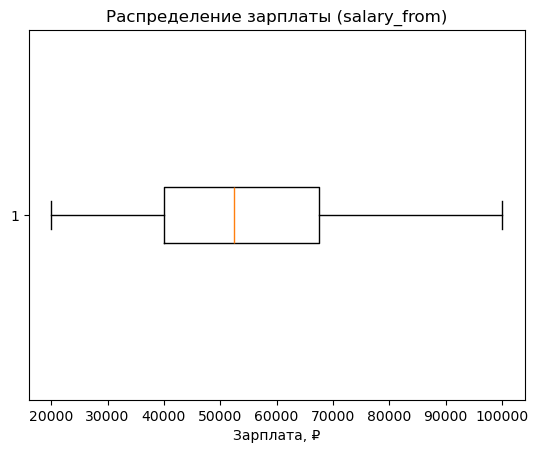

In [27]:
plt.boxplot(
    df_analyst_salary["salary_from"],
    vert=False
)

plt.xlabel("Зарплата, ₽")
plt.title("Распределение зарплаты (salary_from)")
plt.show()

In [28]:
df_analyst_salary['salary_to'].describe()

count        10.000000
mean      87700.000000
std       42158.563121
min       22000.000000
25%       61250.000000
50%       80000.000000
75%      117500.000000
max      150000.000000
Name: salary_to, dtype: float64

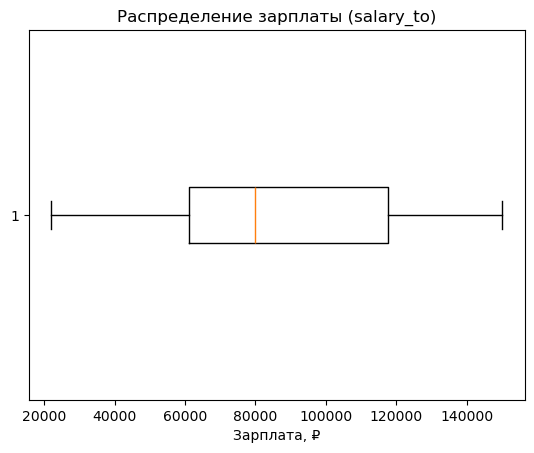

In [29]:
plt.boxplot(
    df_analyst_salary["salary_to"],
    vert=False
)

plt.xlabel("Зарплата, ₽")
plt.title("Распределение зарплаты (salary_to)")
plt.show()

In [30]:
q25_from = df_analyst_salary["salary_from"].quantile(0.25)
q75_from = df_analyst_salary["salary_from"].quantile(0.75)

q25_to = df_analyst_salary["salary_to"].quantile(0.25)
q75_to = df_analyst_salary["salary_to"].quantile(0.75)

mean_from = (q25_from + q75_from) / 2
mean_to = (q25_to + q75_to) / 2

overall_mean = (mean_from + mean_to) / 2

print("Зарплата от:", q25_from, "-", q75_from)
print("Среднее для от:", mean_from)

print("Зарплата до:", q25_to, "-", q75_to)
print("Среднее для до:", mean_to)

print("Общее среднее:", overall_mean)

Зарплата от: 40000.0 - 67500.0
Среднее для от: 53750.0
Зарплата до: 61250.0 - 117500.0
Среднее для до: 89375.0
Общее среднее: 71562.5


Для вакансий аналитика данных, не требующих опыта работы, центральный диапазон зарплаты «от» составляет **40000.0 - 67500.0 ₽**, а зарплаты «до» — **61250.0 - 117500.0 ₽**. Средние значения внутри этих диапазонов составляют **53750.0 ₽** и **89375.0 ₽** соответственно. Таким образом, ориентировочная средняя зарплата по центральному диапазону составляет **71562.5 ₽**.


In [37]:
# посмотрим востребованные скилы
from collections import Counter

skills = df_analyst['key_skills'].dropna().str.split(', ').explode()

skills_count = skills.value_counts()

skills_count.head(15)

key_skills
SQL                                    15
Математическая статистика               7
Python                                  7
Big Data                                5
Базы данных                             5
Аналитический склад ума                 5
Анализ данных                           4
Работа с большим объемом информации     4
Математический анализ                   4
Бизнес-анализ                           3
Системный анализ                        3
BPMN                                    3
API                                     3
Аналитическое мышление                  3
PostgreSQL                              3
Name: count, dtype: int64

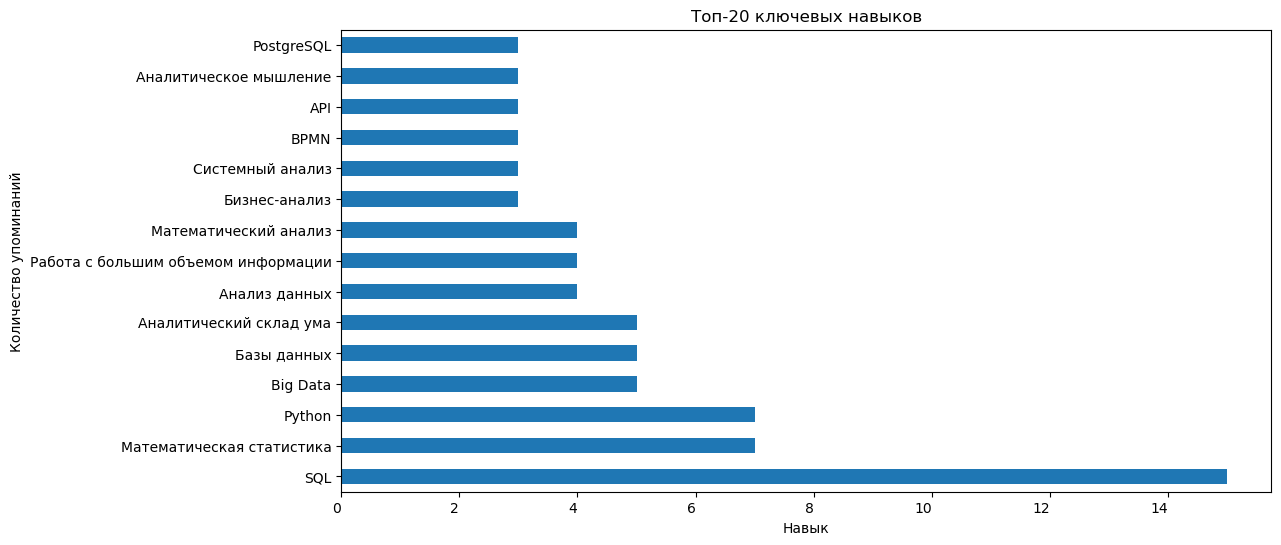

In [40]:
skills_count.head(15).plot(
    kind='barh',
    figsize=(12, 6),
)

plt.title('Топ-20 ключевых навыков')
plt.xlabel('Навык')
plt.ylabel('Количество упоминаний')
plt.xticks(ha='right')
plt.show()

Мои ключевые навыки хорошо соответствуют наиболее востребованным требованиям в выборке: SQL занимает первое место по частоте упоминаний, а Python, математическая статистика и анализ данных также входят в число востребованных компетенций. Это подтверждает актуальность выбранного мной направления развития в аналитике данных.

При этом такие soft skills, как аналитическое мышление и способность работать с большим объёмом информации, я развила на предыдущем месте работы. Эти навыки помогают мне структурировать большие объёмы данных, находить закономерности и делать обоснованные выводы.


#### Общий вывод
